In [1]:
import torch.nn as nn
from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_sobolev_nd import *

Training model with seed 5...
Iter      0 | Train: 1.0045e+00 | Val: 1.2744e+00 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter    500 | Train: 9.5194e-03 | Val: 2.6823e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1000 | Train: 7.6814e-03 | Val: 1.6284e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   1500 | Train: 5.2390e-03 | Val: 1.4359e-02 | Weights: pde=0.471  J2=0.294  J3=0.176  J4=0.059
Iter   2000 | Train: 4.7483e-03 | Val: 1.3989e-02 | Weights: J2=0.111  J3=0.360  pde=0.471  J4=0.059
Iter   2500 | Train: 4.9975e-03 | Val: 1.7497e-02 | Weights: J2=0.111  J3=0.360  pde=0.471  J4=0.059
Iter   3000 | Train: 5.9852e-03 | Val: 1.2447e-02 | Weights: J2=0.319  J3=0.152  pde=0.471  J4=0.059
Iter   3500 | Train: 4.7106e-03 | Val: 1.3078e-02 | Weights: J2=0.319  J3=0.152  pde=0.471  J4=0.059
Iter   4000 | Train: 4.5659e-03 | Val: 9.1378e-03 | Weights: J2=0.169  J3=0.302  pde=0.471  J4=0.059
Iter   4500 | Train: 4.6247e-03 | Val: 8.9917e-03 | Weights: 

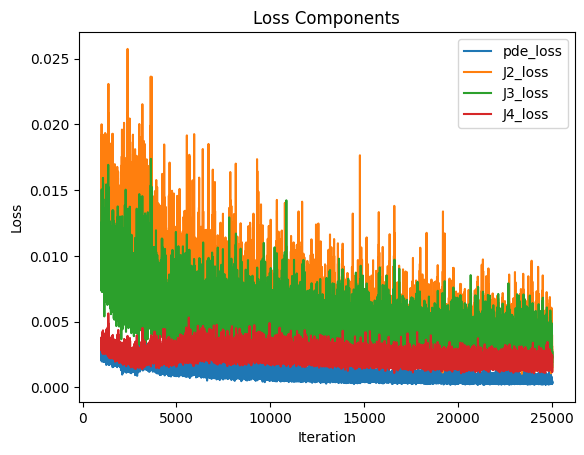

In [2]:
seed = 5
print(f'Training model with seed {seed}...')
pinn = BlackScholesSobolevMultiAsset(model_config, seed=seed)
pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
pinn.set_loss_weights(loss_weights)
pinn.train(batch_size=4096, epochs=25000, early_stopping=None, anneal_freq=1000, alpha=0.9, causal_eps=1, fb_frac=0.5)
pinn.save(f'../../models/bs_sobolev_nd/{seed}.pth')
pinn.plot_losses(detailed=True, start_epoch=1000)